# 8. Multi-modal Knowledge Graph Builder

Builds a Neo4j KG connecting 275 product images to 107 material trend elements (color / texture / decoration) via VLM 3-vote closed-set classification.

**Sections**
1. Environment & Neo4j connection
2. Data loading
3. Neo4j schema & node upsert → `kg_builder.py` Phase A
4. VLM matching pipeline → `kg_builder.py` Phase B + full pipeline run
5. Retrieval interface → `kg_retrieval.py`
6. Validation

## Section 1: Environment & Neo4j Connection

In [4]:
import os
import json
import base64
import asyncio
import logging
from pathlib import Path

import httpx
import numpy as np
from dotenv import load_dotenv
from neo4j import GraphDatabase
from tqdm.notebook import tqdm

load_dotenv()
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

REPO_ROOT = Path().resolve().parent
MATERIAL_DIR = REPO_ROOT / "material_library"
REPORTS_DIR = REPO_ROOT / "reports"


In [5]:
def get_neo4j_driver():
    """Create Neo4j driver from environment variables."""
    uri = os.getenv("NEO4J_URI", "bolt://localhost:7687")
    user = os.getenv("NEO4J_USER", "neo4j")
    password = os.getenv("NEO4J_PASSWORD", "")
    if not password:
        raise ValueError(
            f"NEO4J_PASSWORD is not set. Check your .env. URI: {uri}"
        )
    try:
        driver = GraphDatabase.driver(uri, auth=(user, password))
        driver.verify_connectivity()
        print(f"✓ Connected to Neo4j at {uri}")
        return driver
    except Exception as e:
        raise ConnectionError(
            f"Cannot connect to Neo4j at {uri}. Is it running?\n{e}"
        ) from e

driver = get_neo4j_driver()


✓ Connected to Neo4j at bolt://localhost:7687


## Section 2: Data Loading

In [6]:
def load_materials() -> dict[str, list[dict]]:
    """Load all material elements grouped by dimension key."""
    dim_files = {
        "color": MATERIAL_DIR / "color.json",
        "texture": MATERIAL_DIR / "texture.json",
        "decoration": MATERIAL_DIR / "decoration.json",
    }
    materials = {}
    for dim_key, path in dim_files.items():
        if not path.exists():
            raise FileNotFoundError(f"Missing material file: {path}")
        with open(path) as f:
            data = json.load(f)
        materials[dim_key] = data["elements"]
        print(f"  {dim_key}: {len(data['elements'])} elements loaded")
    return materials

materials = load_materials()
print(f"\nTotal materials: {sum(len(v) for v in materials.values())}")


  color: 38 elements loaded
  texture: 31 elements loaded
  decoration: 38 elements loaded

Total materials: 107


In [7]:
def load_image_metadata() -> list[dict]:
    """Load image metadata from image_embeddings.npz."""
    npz_path = MATERIAL_DIR / "image_embeddings.npz"
    data = np.load(npz_path, allow_pickle=True)
    meta = json.loads(str(data["metadata"]))
    # Filter to only images that exist on disk
    valid = [m for m in meta if Path(m["local_path"]).exists()]
    print(f"Total images with embeddings: {len(meta)}")
    print(f"Images found on disk: {len(valid)}")
    return valid

images_meta = load_image_metadata()


Total images with embeddings: 275
Images found on disk: 275


## Section 3: Neo4j Schema & Node Upsert (`kg_builder.py` Phase A)

In [8]:
%%writefile ../src/deep_research_from_scratch/kg_builder.py
"""Multi-modal Knowledge Graph builder: images ↔ material trend elements."""

from __future__ import annotations

import base64
import json
import logging
import os
from pathlib import Path

import httpx
from neo4j import Driver, GraphDatabase
from pydantic import BaseModel
from tqdm import tqdm

from deep_research_from_scratch.Helper import GenAIToken

logger = logging.getLogger(__name__)

DIMENSION_RELATION = {
    "color": "HAS_COLOR",
    "texture": "HAS_TEXTURE",
    "decoration": "HAS_DECORATION",
}

DIMENSION_LABEL = {
    "color": "颜色",
    "texture": "透明度与质地",
    "decoration": "装饰物",
}


# ── Neo4j connection ──────────────────────────────────────────────────────────

def get_neo4j_driver() -> Driver:
    """Create Neo4j driver from environment variables."""
    uri = os.getenv("NEO4J_URI", "bolt://localhost:7687")
    user = os.getenv("NEO4J_USER", "neo4j")
    password = os.getenv("NEO4J_PASSWORD", "")
    if not password:
        raise ValueError(f"NEO4J_PASSWORD is not set. URI: {uri}")
    try:
        driver = GraphDatabase.driver(uri, auth=(user, password))
        driver.verify_connectivity()
        return driver
    except Exception as e:
        raise ConnectionError(
            f"Cannot connect to Neo4j at {uri}. Is Neo4j running?\n{e}"
        ) from e


# ── Schema initialisation ─────────────────────────────────────────────────────

def init_kg_schema(driver: Driver) -> None:
    """Create unique constraints for Image.path and Material.id."""
    with driver.session() as session:
        session.run(
            "CREATE CONSTRAINT IF NOT EXISTS "
            "FOR (i:Image) REQUIRE i.path IS UNIQUE"
        )
        session.run(
            "CREATE CONSTRAINT IF NOT EXISTS "
            "FOR (m:Material) REQUIRE m.id IS UNIQUE"
        )
    logger.info("Neo4j schema constraints created.")


# ── Node upsert ───────────────────────────────────────────────────────────────

def upsert_image_nodes(driver: Driver, images_meta: list[dict]) -> None:
    """MERGE Image nodes into Neo4j."""
    query = (
        "UNWIND $rows AS row "
        "MERGE (i:Image {path: row.path}) "
        "SET i.description = row.description, "
        "    i.report_id   = row.report_id, "
        "    i.filename    = row.filename"
    )
    rows = [
        {
            "path": m["local_path"],
            "description": m.get("description", ""),
            "report_id": m.get("report_id", ""),
            "filename": Path(m["local_path"]).name,
        }
        for m in images_meta
    ]
    with driver.session() as session:
        session.run(query, rows=rows)
    logger.info("Upserted %d Image nodes.", len(rows))


def upsert_material_nodes(driver: Driver, materials: dict[str, list[dict]]) -> None:
    """MERGE Material nodes into Neo4j."""
    query = (
        "UNWIND $rows AS row "
        "MERGE (m:Material {id: row.id}) "
        "SET m.name            = row.name, "
        "    m.name_en         = row.name_en, "
        "    m.dimension       = row.dimension, "
        "    m.dimension_key   = row.dimension_key, "
        "    m.visual_keywords = row.visual_keywords, "
        "    m.signals         = row.signals, "
        "    m.typical_use     = row.typical_use, "
        "    m.product_category = row.product_category"
    )
    rows = []
    for dim_key, elements in materials.items():
        for el in elements:
            rows.append({
                "id": el["id"],
                "name": el["name"],
                "name_en": el.get("name_en", ""),
                "dimension": el["dimension"],
                "dimension_key": dim_key,
                "visual_keywords": el.get("visual_keywords", []),
                "signals": el.get("signals", []),
                "typical_use": el.get("typical_use", ""),
                "product_category": el.get("product_category", ""),
            })
    with driver.session() as session:
        session.run(query, rows=rows)
    logger.info("Upserted %d Material nodes.", len(rows))


# ── VLM helpers ───────────────────────────────────────────────────────────────

class DimensionMatches(BaseModel):
    """Structured output for VLM closed-set classification."""

    matched_material_ids: list[str]


_MATCH_SYSTEM_PROMPT = """You are an expert in beauty product visual analysis.
Your task: analyse the CONTENTS of a product image (liquid, cream, gel, scrub particles etc.)
and identify which trend material elements are visually represented.

IMPORTANT rules:
- Focus ONLY on the product contents (liquid colour, texture, decorative particles etc.)
- IGNORE outer packaging, bottle shape, labels, box design
- Return ONLY material IDs from the provided list — do not invent new IDs
- It is OK to return an empty list if nothing matches
"""

def _image_to_inline_part(path: str) -> dict:
    """Base64-encode a local image file into a Gemini inlineData part."""
    import mimetypes
    p = Path(path)
    data = p.read_bytes()
    mime, _ = mimetypes.guess_type(p.name)
    if mime is None:
        ext = p.suffix.lower()
        mime = {
            ".jpg": "image/jpeg", ".jpeg": "image/jpeg", ".png": "image/png",
            ".webp": "image/webp", ".gif": "image/gif", ".bmp": "image/bmp",
        }.get(ext, "image/jpeg")
    return {"inlineData": {"mimeType": mime, "data": base64.b64encode(data).decode()}}


def build_dimension_prompt(
    image_path: str,
    materials: list[dict],
    dimension_label: str,
) -> list[dict]:
    """Build Gemini contents payload for closed-set dimension matching."""
    mat_lines = []
    for m in materials:
        kws = ", ".join(m.get("visual_keywords", [])[:10])
        mat_lines.append(f'- ID: {m["id"]} | Name: {m["name"]} | Keywords: {kws}')
    mat_text = "\n".join(mat_lines)

    prompt_text = (
        f"{_MATCH_SYSTEM_PROMPT}\n\n"
        f"Dimension: {dimension_label}\n\n"
        f"Material candidates:\n{mat_text}\n\n"
        "Look at the image. Which of the above materials are visually present in "
        "the product contents?\n"
        'Return JSON only: {"matched_material_ids": ["id1", "id2"]}'
    )
    return [
        {
            "parts": [
                _image_to_inline_part(image_path),
                {"text": prompt_text},
            ]
        }
    ]


def _call_vlm_once(
    url: str,
    headers: dict,
    contents: list[dict],
    valid_ids: set[str],
) -> list[str]:
    """Call VLM once and return list of valid matched material IDs."""
    payload = {
        "contents": contents,
        "config": {"response_modalities": ["text"]},
    }
    with httpx.Client(trust_env=True, timeout=httpx.Timeout(60.0)) as client:
        resp = client.post(url, headers=headers, json=payload)
    resp.raise_for_status()
    data = resp.json()
    text = (
        data.get("candidates", [{}])[0]
        .get("content", {})
        .get("parts", [{}])[0]
        .get("text", "{}")
        .strip()
    )
    # Strip markdown code fences if present
    if text.startswith("```"):
        text = "\n".join(text.split("\n")[1:])
        text = text.rstrip("`").strip()
    try:
        parsed = json.loads(text)
        ids = parsed.get("matched_material_ids", [])
        return [i for i in ids if i in valid_ids]
    except json.JSONDecodeError:
        logger.warning("VLM returned non-JSON: %s", text[:200])
        return []


def run_vlm_match(
    image_path: str,
    materials: dict[str, list[dict]],
) -> dict[str, list[list[str]]]:
    """Run VLM 3×3 matching for one image across all three dimensions.

    Returns:
        {dimension_key: [run1_ids, run2_ids, run3_ids]}
    """
    nano_url = os.getenv("NANO_BANANA_URL", "").strip()
    if not nano_url:
        raise ValueError("NANO_BANANA_URL is not set.")

    headers = {
        "userid": os.getenv("HEADERS_USERID", ""),
        "project-name": os.getenv("HEADERS_PROJECT_NAME", ""),
        "Authorization": f"Bearer {GenAIToken().token()}",
    }

    results: dict[str, list[list[str]]] = {}
    for dim_key, dim_materials in materials.items():
        valid_ids = {m["id"] for m in dim_materials}
        contents = build_dimension_prompt(image_path, dim_materials, DIMENSION_LABEL[dim_key])
        runs = []
        for _ in range(3):
            try:
                matched = _call_vlm_once(nano_url, headers, contents, valid_ids)
                runs.append(matched)
            except Exception as exc:  # noqa: BLE001
                logger.warning("VLM call failed for %s / %s: %s", image_path, dim_key, exc)
                runs.append([])
        results[dim_key] = runs

    return results


def compute_consensus(runs: list[list[str]]) -> list[str]:
    """Return material IDs that appear in ALL three VLM runs."""
    if not runs or any(len(r) == 0 and len(runs[0]) > 0 for r in runs):
        # If any run errored (empty) but others had results, be conservative
        pass
    if len(runs) < 3:
        return []
    sets = [set(r) for r in runs]
    consensus = sets[0].intersection(*sets[1:])
    return list(consensus)


def upsert_edges(
    driver: Driver,
    image_path: str,
    consensus_by_dim: dict[str, list[str]],
) -> None:
    """Write consensus-matched edges into Neo4j."""
    with driver.session() as session:
        for dim_key, material_ids in consensus_by_dim.items():
            rel_type = DIMENSION_RELATION[dim_key]
            for mat_id in material_ids:
                session.run(
                    f"MATCH (i:Image {{path: $path}}), (m:Material {{id: $mat_id}}) "
                    f"MERGE (i)-[:{rel_type}]->(m)",
                    path=image_path,
                    mat_id=mat_id,
                )


def get_processed_image_paths(driver: Driver) -> set[str]:
    """Return paths of Image nodes already fully processed (present in Neo4j)."""
    with driver.session() as session:
        result = session.run("MATCH (i:Image) RETURN i.path AS path")
        return {record["path"] for record in result}


# ── Full pipeline ─────────────────────────────────────────────────────────────

def build_kg(
    driver: Driver,
    images_meta: list[dict],
    materials: dict[str, list[dict]],
    dry_run: bool = False,
) -> None:
    """Run full KG building pipeline with incremental skip for existing images."""
    init_kg_schema(driver)
    upsert_image_nodes(driver, images_meta)
    upsert_material_nodes(driver, materials)

    # An image is considered "done" if it has at least one outgoing relationship
    with driver.session() as session:
        result = session.run(
            "MATCH (i:Image)-[r]->() RETURN DISTINCT i.path AS path"
        )
        done_paths = {record["path"] for record in result}

    new_images = [m for m in images_meta if m["local_path"] not in done_paths]
    logger.info(
        "Images to process: %d (skipping %d already done)",
        len(new_images), len(done_paths),
    )

    if dry_run:
        logger.info("Dry run — skipping VLM calls.")
        return

    for img_meta in tqdm(new_images, desc="Building KG edges"):
        image_path = img_meta["local_path"]
        try:
            runs_by_dim = run_vlm_match(image_path, materials)
            consensus_by_dim = {
                dim: compute_consensus(runs)
                for dim, runs in runs_by_dim.items()
            }
            upsert_edges(driver, image_path, consensus_by_dim)
        except Exception as exc:  # noqa: BLE001
            logger.error("Failed to process %s: %s", image_path, exc)


Overwriting ../src/deep_research_from_scratch/kg_builder.py


In [9]:
# Run Phase A: schema + node upsert
import importlib, sys
sys.path.insert(0, str(REPO_ROOT / "src"))

from deep_research_from_scratch import kg_builder
importlib.reload(kg_builder)

kg_builder.init_kg_schema(driver)
kg_builder.upsert_image_nodes(driver, images_meta)
kg_builder.upsert_material_nodes(driver, materials)

with driver.session() as s:
    result = s.run("MATCH (n) RETURN labels(n) AS lbl, count(n) AS cnt")
    for r in result:
        print(f"  {r['lbl']}: {r['cnt']}")


INFO:deep_research_from_scratch.kg_builder:Neo4j schema constraints created.
INFO:deep_research_from_scratch.kg_builder:Upserted 275 Image nodes.
INFO:deep_research_from_scratch.kg_builder:Upserted 107 Material nodes.


  ['Image']: 275
  ['Material']: 107


## Section 4: VLM Matching Pipeline

Runs 3-vote closed-set VLM classification for each image × dimension. Only builds edges where all 3 runs agree.

Testing VLM on: 001_1ec2ec847113a5c5af44c3100168cd46.png
Description: 三支磨砂膏软管包装，米白奶油粉配色，简约高级质感


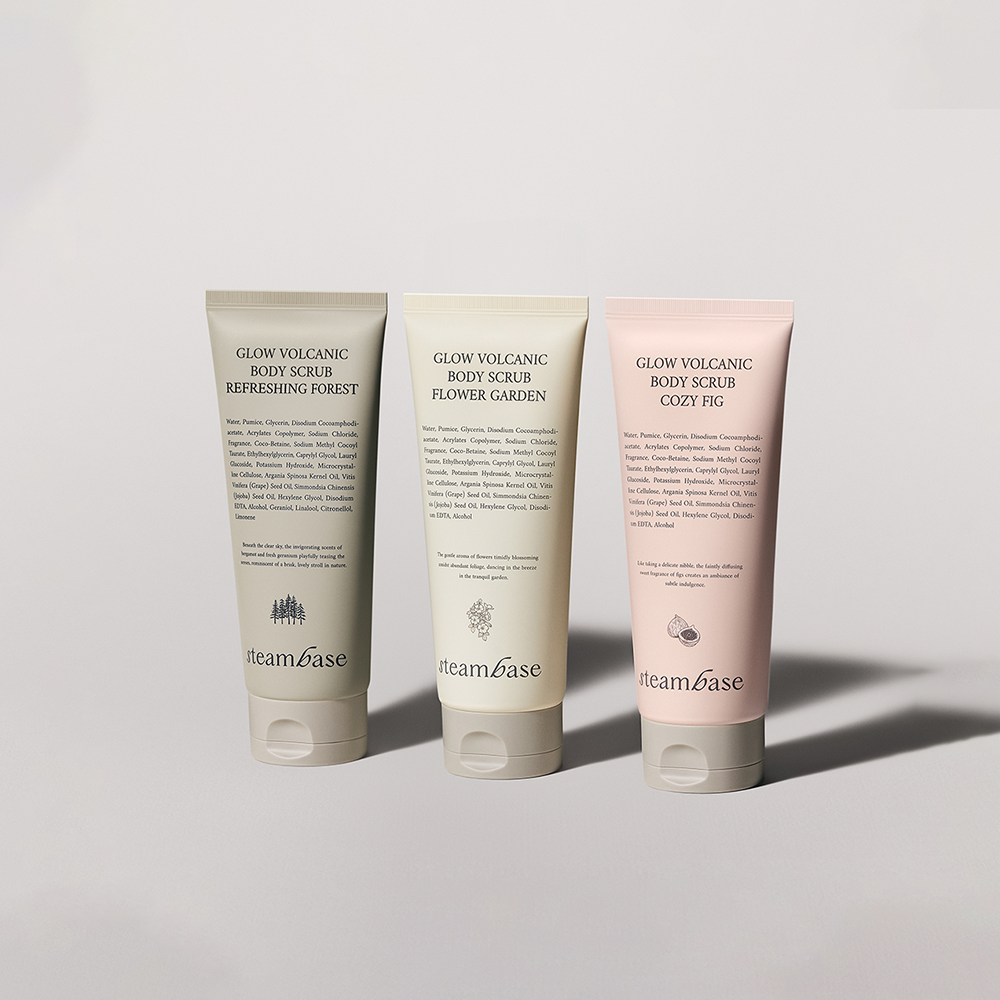

INFO:httpx:HTTP Request: POST https://genai-platform-dev.pg.com/stg/v1/vertexai/v1/projects/genai-platform/locations/any/publishers/google/models/gemini-2.5-flash-image:generateContent "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://genai-platform-dev.pg.com/stg/v1/vertexai/v1/projects/genai-platform/locations/any/publishers/google/models/gemini-2.5-flash-image:generateContent "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://genai-platform-dev.pg.com/stg/v1/vertexai/v1/projects/genai-platform/locations/any/publishers/google/models/gemini-2.5-flash-image:generateContent "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://genai-platform-dev.pg.com/stg/v1/vertexai/v1/projects/genai-platform/locations/any/publishers/google/models/gemini-2.5-flash-image:generateContent "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://genai-platform-dev.pg.com/stg/v1/vertexai/v1/projects/genai-platform/locations/any/publishers/google/models/gemini-2.5-flash-image:generateContent "HT


[color]
  Run 1: ['25fccecd-color-9a98e69a-93014b (自然香型映射色彩)']
  Run 2: ['25fccecd-color-9a98e69a-93014b (自然香型映射色彩)']
  Run 3: ['25fccecd-color-9a98e69a-93014b (自然香型映射色彩)']
  Consensus: ['25fccecd-color-9a98e69a-93014b (自然香型映射色彩)']

[texture]
  Run 1: []
  Run 2: []
  Run 3: []
  Consensus: []

[decoration]
  Run 1: []
  Run 2: ['25fccecd-decoration-4ed4803e-010b4b (草本纤维)']
  Run 3: []
  Consensus: []


In [11]:
# Dry-run test: verify VLM call works on 1 image (no Neo4j writes)
from IPython.display import Image, display

test_image = images_meta[0]
image_path = test_image["local_path"]
print(f"Testing VLM on: {Path(image_path).name}")
print(f"Description: {test_image.get('description', '')}")
display(Image(filename=image_path, width=320))

# Build lookup once: material id -> material name
id_to_name = {
    m["id"]: m["name"]
    for dim_elements in materials.values()
    for m in dim_elements
}

def format_matches(ids: list[str]) -> list[str]:
    """Convert material ids to readable 'id (name)' strings."""
    return [f"{mid} ({id_to_name.get(mid, 'UNKNOWN')})" for mid in ids]

runs = kg_builder.run_vlm_match(image_path, materials)
for dim, dim_runs in runs.items():
    consensus = kg_builder.compute_consensus(dim_runs)
    print(f"\n[{dim}]")
    for i, run_ids in enumerate(dim_runs, 1):
        print(f"  Run {i}: {format_matches(run_ids)}")
    print(f"  Consensus: {format_matches(consensus)}")


In [ ]:
# Trial run: process 5 images with edge writes
trial_images = images_meta[:5]
print(f"Processing {len(trial_images)} images...")

for img_meta in trial_images:
    runs_by_dim = kg_builder.run_vlm_match(img_meta["local_path"], materials)
    consensus_by_dim = {
        dim: kg_builder.compute_consensus(runs)
        for dim, runs in runs_by_dim.items()
    }
    kg_builder.upsert_edges(driver, img_meta["local_path"], consensus_by_dim)
    total = sum(len(v) for v in consensus_by_dim.values())
    print(f"  {Path(img_meta['local_path']).name}: {total} edges created")

with driver.session() as s:
    r = s.run("MATCH (i:Image)-[r]->(m:Material) RETURN type(r), count(r) AS cnt")
    for rec in r:
        print(f"  {rec['type(r)']}: {rec['cnt']} edges")


In [ ]:
# Full pipeline run (incremental — skips already-processed images)
kg_builder.build_kg(driver, images_meta, materials)

# Summary
with driver.session() as s:
    result = s.run(
        "MATCH (i:Image)-[r]->(m:Material) "
        "RETURN type(r) AS rel, count(r) AS cnt"
    )
    print("\nEdge summary:")
    total = 0
    for rec in result:
        print(f"  {rec['rel']}: {rec['cnt']}")
        total += rec['cnt']
    print(f"  Total: {total}")


## Section 5: Retrieval Interface (`kg_retrieval.py`)

In [ ]:
%%writefile ../src/deep_research_from_scratch/kg_retrieval.py
"""Neo4j query interface for the multi-modal material knowledge graph."""

from __future__ import annotations

from neo4j import Driver

DIMENSION_RELATIONS = {"color": "HAS_COLOR", "texture": "HAS_TEXTURE", "decoration": "HAS_DECORATION"}


def get_images_for_material(
    driver: Driver,
    material_id: str | None = None,
    material_name: str | None = None,
    relation: str | None = None,
    report_id: str | None = None,
) -> list[dict]:
    """Return images connected to a material element.

    Args:
        driver: Neo4j driver.
        material_id: Match by material id (exact).
        material_name: Match by material name (exact).
        relation: One of 'HAS_COLOR', 'HAS_TEXTURE', 'HAS_DECORATION'.
                  If None, matches any relation.
        report_id: Filter images by report_id.

    Returns:
        List of image property dicts (path, description, report_id, filename).
    """
    if material_id is None and material_name is None:
        raise ValueError("Provide either material_id or material_name.")

    rel_clause = f"[:{relation}]" if relation else "[]"
    if material_id:
        mat_match = "{id: $mat_key}"
        mat_key = material_id
    else:
        mat_match = "{name: $mat_key}"
        mat_key = material_name

    report_filter = "AND i.report_id = $report_id" if report_id else ""

    query = (
        f"MATCH (i:Image)-{rel_clause}->(m:Material {mat_match}) "
        f"WHERE 1=1 {report_filter} "
        "RETURN i.path AS path, i.description AS description, "
        "       i.report_id AS report_id, i.filename AS filename"
    )
    params: dict = {"mat_key": mat_key}
    if report_id:
        params["report_id"] = report_id

    with driver.session() as session:
        result = session.run(query, **params)
        return [dict(r) for r in result]


def get_material_image_counts(
    driver: Driver,
    dimension: str | None = None,
) -> list[dict]:
    """Return image counts per material, sorted descending.

    Args:
        driver: Neo4j driver.
        dimension: Filter by dimension label (e.g. '颜色'). None = all.

    Returns:
        List of {material_id, material_name, dimension, image_count} dicts.
    """
    dim_filter = "WHERE m.dimension = $dimension" if dimension else ""
    query = (
        "MATCH (i:Image)-[]->(m:Material) "
        f"{dim_filter} "
        "RETURN m.id AS material_id, m.name AS material_name, "
        "       m.dimension AS dimension, count(i) AS image_count "
        "ORDER BY image_count DESC"
    )
    params = {"dimension": dimension} if dimension else {}
    with driver.session() as session:
        result = session.run(query, **params)
        return [dict(r) for r in result]


In [ ]:
# Demo: find representative images for '低饱和香氛色'
from deep_research_from_scratch import kg_retrieval
importlib.reload(kg_retrieval)

images = kg_retrieval.get_images_for_material(driver, material_name="低饱和香氛色")
print(f"Representative images for '低饱和香氛色': {len(images)}")
for img in images[:5]:
    print(f"  [{img['report_id'][:8]}] {img['filename']}: {img['description'][:60]}")


In [ ]:
# Show top materials by image count
counts = kg_retrieval.get_material_image_counts(driver, dimension="颜色")
print("Top color materials by representative image count:")
for row in counts[:10]:
    print(f"  {row['material_name']}: {row['image_count']} images")


## Section 6: Validation

In [ ]:
# 7.1 Acceptance Cypher
with driver.session() as s:
    print("Edge type counts:")
    for rec in s.run("MATCH (i:Image)-[r]->(m:Material) RETURN type(r), count(r) AS cnt"):
        print(f"  {rec['type(r)']}: {rec['cnt']}")

    print("\nNode counts:")
    for rec in s.run("MATCH (n) RETURN labels(n) AS lbl, count(n) AS cnt"):
        print(f"  {rec['lbl']}: {rec['cnt']}")


In [ ]:
# 7.2 Manual spot-check: pick 3 materials and show their top representative images
spot_check = ["低饱和香氛色", "透明液体感", "金色/粉色珠光微粒"]
for name in spot_check:
    imgs = kg_retrieval.get_images_for_material(driver, material_name=name)
    print(f"\n'{name}' ({len(imgs)} images):")
    for img in imgs[:3]:
        print(f"  {img['filename']}: {img.get('description','')[:70]}")


In [ ]:
driver.close()
print("Done.")
